## Business Question

Which products and categories generate the most sales, revenue, and customer satisfaction, and where should the business focus growth or improvement efforts?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

if (Path.cwd() / "data" / "raw").exists():
    DATA_PATH = Path.cwd() / "data" / "raw"
elif (Path.cwd().parent / "data" / "raw").exists():
    DATA_PATH = Path.cwd().parent / "data" / "raw"
else:
    raise FileNotFoundError("Could not find the data/raw folder.")

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [2]:
sales = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
    .merge(orders, on="order_id", how="left")
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
)

category_units = (
    sales.groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        avg_review_score=("review_score", "mean"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean")
    )
    .reset_index()
    .sort_values("units_sold", ascending=False)
)

category_units.head(15)

,product_category_name_english,orders,units_sold,revenue,avg_review_score,avg_price,avg_freight
7,bed_bath_table,9417,11270,1050936.61,3.895663,93.250808,18.389787
43,health_beauty,8836,9727,1263138.54,4.142768,129.859005,18.863323
65,sports_leisure,7720,8700,993656.51,4.107986,114.213392,19.502698
39,furniture_decor,6449,8415,736282.47,3.903493,87.496431,20.724965
15,computers_accessories,6689,7894,919640.54,3.930819,116.498675,18.802881
49,housewares,5884,6989,634542.60,4.055019,90.791615,20.979744
70,watches_gifts,5624,6001,1206075.33,4.019160,200.979058,16.778215
68,telephony,4199,4550,323839.40,3.946867,71.173495,15.681666
42,garden_tools,3518,4361,486432.45,4.042735,111.541493,22.750307
5,auto,3897,4256,594363.10,4.065512,139.652984,21.854109


### Finding 1

The highest-volume categories are **Bed Bath Table**, **Health Beauty**, and **Sports Leisure**, indicating consistently strong customer demand.

Although these categories generate the highest number of units sold, their average review scores remain between **3.9 and 4.15**, suggesting that high sales volume does not necessarily translate into exceptional customer satisfaction.

Health Beauty stands out by combining both high sales volume and strong revenue generation.

In [3]:
category_revenue = category_units.sort_values("revenue", ascending=False)
category_revenue.head(15)

,product_category_name_english,orders,units_sold,revenue,avg_review_score,avg_price,avg_freight
43,health_beauty,8836,9727,1263138.54,4.142768,129.859005,18.863323
70,watches_gifts,5624,6001,1206075.33,4.019160,200.979058,16.778215
7,bed_bath_table,9417,11270,1050936.61,3.895663,93.250808,18.389787
65,sports_leisure,7720,8700,993656.51,4.107986,114.213392,19.502698
15,computers_accessories,6689,7894,919640.54,3.930819,116.498675,18.802881
39,furniture_decor,6449,8415,736282.47,3.903493,87.496431,20.724965
20,cool_stuff,3632,3806,637258.51,4.146341,167.435236,22.131999
49,housewares,5884,6989,634542.60,4.055019,90.791615,20.979744
5,auto,3897,4256,594363.10,4.065512,139.652984,21.854109
42,garden_tools,3518,4361,486432.45,4.042735,111.541493,22.750307


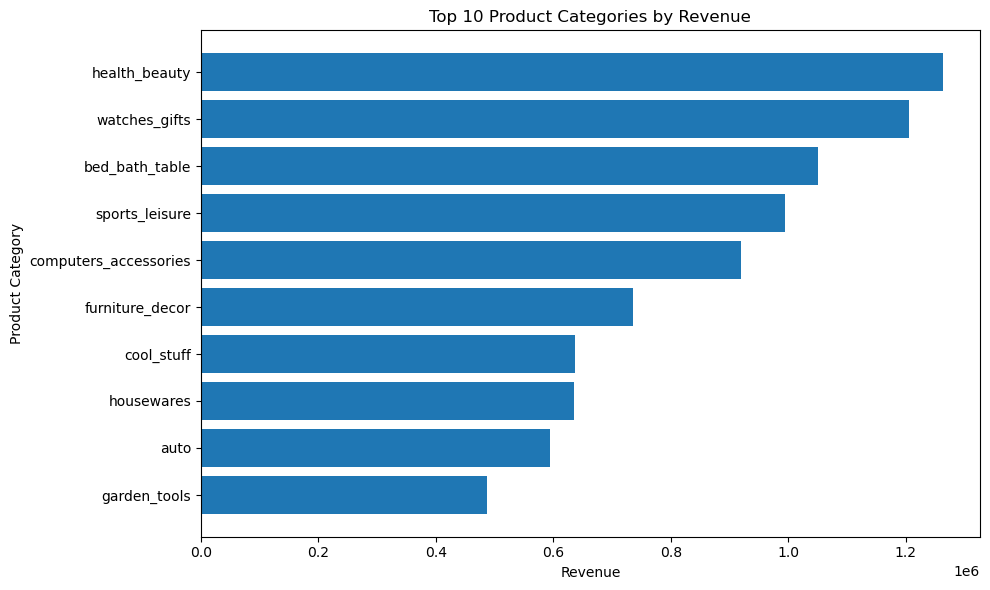

In [4]:
top_10_revenue = category_revenue.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_revenue["product_category_name_english"],
    top_10_revenue["revenue"]
)
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Finding 2

Revenue concentration differs slightly from unit sales.

While Bed Bath Table leads in units sold, **Health Beauty** generates the highest overall revenue, followed closely by **Watches Gifts**.

This indicates that some categories achieve higher revenue through higher average selling prices rather than sales volume alone.

In [5]:
high_revenue_low_rating = (
    category_units[
        (category_units["orders"] >= 100) &
        (category_units["avg_review_score"] < category_units["avg_review_score"].mean())
    ]
    .sort_values("revenue", ascending=False)
)

high_revenue_low_rating.head(15)

,product_category_name_english,orders,units_sold,revenue,avg_review_score,avg_price,avg_freight
70,watches_gifts,5624,6001,1206075.33,4.019160,200.979058,16.778215
7,bed_bath_table,9417,11270,1050936.61,3.895663,93.250808,18.389787
15,computers_accessories,6689,7894,919640.54,3.930819,116.498675,18.802881
39,furniture_decor,6449,8415,736282.47,3.903493,87.496431,20.724965
6,baby,2885,3073,412117.47,4.011811,134.109167,22.300615
68,telephony,4199,4550,323839.40,3.946867,71.173495,15.681666
57,office_furniture,1273,1701,275224.49,3.493183,161.801581,40.481052
26,electronics,2550,2768,160376.64,4.037468,57.939538,16.839809
16,consoles_games,1062,1138,158000.22,4.023070,138.840264,17.437891
48,home_construction,490,605,83207.97,3.940000,137.533835,22.882810


### Finding 3

Several high-revenue categories perform below the overall average customer satisfaction score.

These categories should receive priority operational attention because improvements in customer experience could protect significant revenue while reducing future negative reviews.

In [6]:
best_rated_categories = (
    category_units[category_units["orders"] >= 100]
    .sort_values("avg_review_score", ascending=False)
)

best_rated_categories.head(15)

,product_category_name_english,orders,units_sold,revenue,avg_review_score,avg_price,avg_freight
8,books_general_interest,512,553,46856.88,4.446266,84.732152,16.628427
10,books_technical,260,269,19149.03,4.368421,71.185985,16.013011
37,food_drink,227,280,15270.47,4.315412,54.537393,16.272607
53,luggage_accessories,1034,1092,140429.98,4.315257,128.598883,27.880247
31,fashion_shoes,240,265,23767.47,4.233716,89.688566,18.741132
36,food,450,510,29393.41,4.218182,57.634137,14.256922
66,stationery,2311,2525,231300.21,4.193857,91.604044,18.583739
60,pet_shop,1710,1949,214591.41,4.185147,110.103340,20.317794
14,computers,181,203,222963.13,4.175000,1098.340542,48.454680
44,home_appliances,764,809,83195.60,4.172457,102.837577,19.237095


### Finding 4

Several categories maintain both strong customer ratings and meaningful sales volume.

These categories represent ideal candidates for promotional campaigns, homepage placement, cross-selling opportunities, and customer retention initiatives because they combine commercial success with consistently positive customer experiences.

In [7]:
worst_rated_categories = (
    category_units[category_units["orders"] >= 100]
    .sort_values("avg_review_score")
)

worst_rated_categories.head(15)

,product_category_name_english,orders,units_sold,revenue,avg_review_score,avg_price,avg_freight
57,office_furniture,1273,1701,275224.49,3.493183,161.801581,40.481052
30,fashion_male_clothing,112,132,10797.82,3.641221,81.801667,16.306136
34,fixed_telephony,217,265,59622.99,3.683206,224.992415,17.579660
4,audio,350,365,50738.40,3.825485,139.009315,15.683671
47,home_confort,397,437,58828.74,3.829885,134.619542,19.568581
19,construction_tools_safety,167,194,40544.52,3.844560,208.992371,20.201546
7,bed_bath_table,9417,11270,1050936.61,3.895663,93.250808,18.389787
39,furniture_decor,6449,8415,736282.47,3.903493,87.496431,20.724965
40,furniture_living_room,422,507,69427.26,3.904382,136.937396,35.693688
15,computers_accessories,6689,7894,919640.54,3.930819,116.498675,18.802881


### Finding 5

Office Furniture has the lowest average customer rating among categories with meaningful sales volume.

Combined with relatively high freight costs and longer delivery times identified later in the analysis, this category should be prioritised for operational review to determine whether customer dissatisfaction is driven by logistics, product quality, or supplier performance.

In [8]:
sales["order_purchase_timestamp"] = pd.to_datetime(
    sales["order_purchase_timestamp"],
    errors="coerce"
)

sales["order_delivered_customer_date"] = pd.to_datetime(
    sales["order_delivered_customer_date"],
    errors="coerce"
)

sales["order_estimated_delivery_date"] = pd.to_datetime(
    sales["order_estimated_delivery_date"],
    errors="coerce"
)

sales["delivery_days"] = (
    sales["order_delivered_customer_date"] - sales["order_purchase_timestamp"]
).dt.days

sales["late_delivery"] = (
    sales["order_delivered_customer_date"] > sales["order_estimated_delivery_date"]
)

category_delivery = (
    sales.groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("late_delivery", "mean"),
        avg_review_score=("review_score", "mean"),
        revenue=("price", "sum")
    )
    .reset_index()
)

category_delivery = category_delivery[category_delivery["orders"] >= 100]
category_delivery.sort_values("late_delivery_rate", ascending=False).head(15)

,product_category_name_english,orders,avg_delivery_days,late_delivery_rate,avg_review_score,revenue
4,audio,350,12.892562,0.126027,3.825485,50738.40
33,fashion_underwear_beach,121,13.275591,0.122137,3.976923,9541.55
12,christmas_supplies,128,15.300000,0.117647,4.020548,8800.82
10,books_technical,260,10.233962,0.107807,4.368421,19149.03
47,home_confort,397,13.027778,0.100686,3.829885,58828.74
18,construction_tools_lights,244,9.225166,0.098361,4.054054,41308.00
26,electronics,2550,12.426374,0.096098,4.037468,160376.64
36,food,450,9.100200,0.096078,4.218182,29393.41
43,health_beauty,8836,11.523684,0.088722,4.142768,1263138.54
57,office_furniture,1273,20.397497,0.088183,3.493183,275224.49


### Finding 6

Delivery performance varies across product categories.

Although some categories experience higher late-delivery rates, the relationship with customer satisfaction is not always direct. This suggests that product expectations, order complexity, and product characteristics may also influence customer reviews.

Further investigation should focus on categories that combine high revenue, low ratings, and poor delivery performance.

In [9]:
sales["purchase_month"] = sales["order_purchase_timestamp"].dt.to_period("M")

monthly_sales = (
    sales.groupby("purchase_month")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

monthly_sales

,purchase_month,orders,units_sold,revenue,avg_review_score
0,2016-09,3,6,267.36,1.000000
1,2016-10,308,367,49634.35,3.612188
2,2016-12,1,1,10.90,5.000000
3,2017-01,789,966,121087.90,4.069110
4,2017-02,1733,1962,248563.02,4.054331
5,2017-03,2641,3020,376010.70,4.059118
6,2017-04,2391,2693,360738.17,4.004494
7,2017-05,3660,4182,509639.63,4.136649
8,2017-06,3217,3619,436550.89,4.133593
9,2017-07,3969,4565,501299.70,4.139196


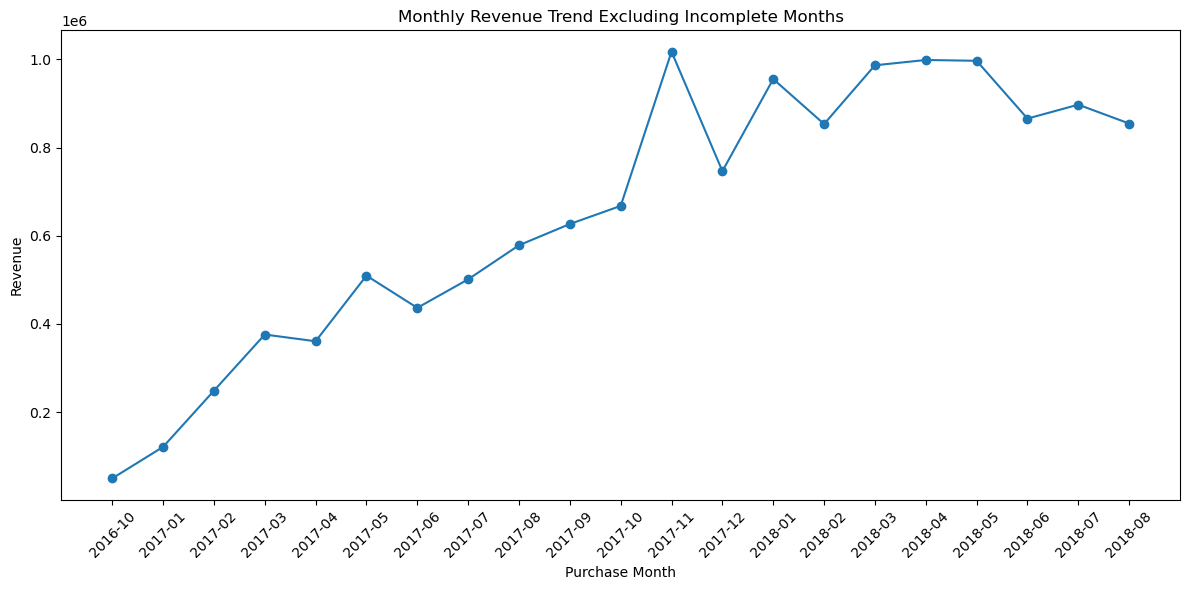

In [10]:
monthly_sales_complete = monthly_sales[
    ~monthly_sales["purchase_month"].astype(str).isin(["2016-09", "2016-12", "2018-09"])
]

monthly_sales_chart = monthly_sales_complete.copy()
monthly_sales_chart["purchase_month"] = monthly_sales_chart["purchase_month"].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales_chart["purchase_month"],
    monthly_sales_chart["revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend Excluding Incomplete Months")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding 7

Monthly sales activity increased steadily throughout 2017 before peaking during November 2017, likely influenced by Black Friday promotions and seasonal demand.

The partial months at the beginning (September 2016) and end (September 2018) represent incomplete data collection periods and should not be interpreted as actual sales declines.

# Overall Business Summary

This analysis combined sales performance, customer satisfaction, revenue generation, and delivery performance to identify commercial opportunities across product categories.

## Key Findings

- Health Beauty generates the highest overall revenue while maintaining strong customer satisfaction.
- Bed Bath Table remains the highest-volume category but performs below the overall average review score.
- Watches Gifts achieves exceptional revenue despite lower sales volume, suggesting a higher average transaction value.
- Several high-revenue categories underperform in customer satisfaction and should be prioritised for operational improvements.
- Office Furniture presents one of the weakest category profiles, combining low customer satisfaction, high freight costs, and longer delivery times.
- Highly rated categories such as Books, Food & Drink, and Luggage Accessories represent opportunities for additional promotion and cross-selling.
- Monthly sales suggest seasonal demand patterns, with significant growth during late 2017.

## Business Recommendations

1. Increase marketing investment in high-performing categories that combine strong revenue and customer satisfaction.

2. Prioritise operational improvements for high-revenue categories with below-average customer ratings.

3. Investigate Office Furniture to determine whether delivery, supplier quality, or product expectations are driving negative reviews.

4. Promote highly rated categories through homepage placement, bundles, and personalised recommendations.

5. Continue monitoring seasonal purchasing behaviour to optimise inventory planning and promotional campaigns.

6. Combine delivery performance metrics with customer satisfaction monitoring to identify operational issues before they significantly affect sales.